<a href="https://colab.research.google.com/github/ranimiftah12345678/ML_22_Ranimiftah/blob/main/JS05/JS05_TUGAS02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load dan preprocessing

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

# Load data (encoding latin-1 karena data bukan UTF-8)
df = pd.read_csv('spam.csv', encoding='latin-1')

# Ambil 2 kolom pertama saja, lalu rename
df = df.iloc[:, :2]
df.columns = ['Labels', 'SMS']

# Encode label: spam = 1, ham = 0
df['Labels'] = df['Labels'].map({'spam': 1, 'ham': 0})

print(df.shape)
print(df['Labels'].value_counts())
df.head()

(5572, 2)
Labels
0    4825
1     747
Name: count, dtype: int64


,Labels,SMS
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [2]:
# Pisahkan fitur dan label, lalu split SEBELUM ekstraksi fitur (mencegah data leakage)
X = df['SMS'].values
y = df['Labels'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)
print('Train:', len(X_train), '| Test:', len(X_test))

Train: 4457 | Test: 1115


Fungsi evaluasi

In [3]:
def evaluasi(nama, vectorizer):
    # fit_transform hanya pada data train, transform pada data test
    A = vectorizer.fit_transform(X_train)
    B = vectorizer.transform(X_test)

    model = MultinomialNB().fit(A, y_train)
    p_tr, p_te = model.predict(A), model.predict(B)

    print(f'===== {nama} =====')
    print('Jumlah fitur :', A.shape[1])
    print('Akurasi train:', accuracy_score(y_train, p_tr))
    print('Akurasi test :', accuracy_score(y_test, p_te))
    print(classification_report(y_test, p_te, target_names=['ham', 'spam']))
    print('Confusion matrix:\n', confusion_matrix(y_test, p_te), '\n')

    return {'Model': nama, 'Jml fitur': A.shape[1],
            'Akurasi train': accuracy_score(y_train, p_tr),
            'Akurasi test': accuracy_score(y_test, p_te),
            'Precision spam': precision_score(y_test, p_te),
            'Recall spam': recall_score(y_test, p_te),
            'F1 spam': f1_score(y_test, p_te)}, p_te

Model 1, CountVectorizer + stop_words

In [4]:
hasil1, pred1 = evaluasi('CountVectorizer + stop_words',
                         CountVectorizer(stop_words='english'))

===== CountVectorizer + stop_words =====
Jumlah fitur : 7466
Akurasi train: 0.9946152120260264
Akurasi test : 0.9829596412556054
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       954
        spam       0.98      0.90      0.94       161

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115

Confusion matrix:
 [[951   3]
 [ 16 145]] 



Model 2, TF-IDF + stop_words

In [5]:
hasil2, pred2 = evaluasi('TF-IDF + stop_words',
                         TfidfVectorizer(stop_words='english'))

===== TF-IDF + stop_words =====
Jumlah fitur : 7466
Akurasi train: 0.9842943684092439
Akurasi test : 0.9605381165919282
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       954
        spam       1.00      0.73      0.84       161

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115

Confusion matrix:
 [[954   0]
 [ 44 117]] 



Perbandingan

,Model,Jml fitur,Akurasi train,Akurasi test,Precision spam,Recall spam,F1 spam
0,CountVectorizer + stop_words,7466,0.9946,0.9830,0.9797,0.9006,0.9385
1,TF-IDF + stop_words,7466,0.9843,0.9605,1.0000,0.7267,0.8417


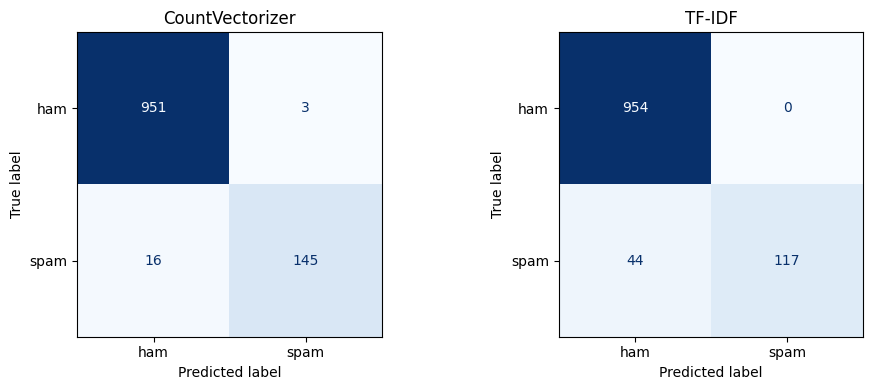

In [6]:
perbandingan = pd.DataFrame([hasil1, hasil2]).round(4)
display(perbandingan)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, nm, p in zip(ax, ['CountVectorizer', 'TF-IDF'], [pred1, pred2]):
    ConfusionMatrixDisplay(confusion_matrix(y_test, p),
                           display_labels=['ham', 'spam']).plot(ax=a, cmap='Blues', colorbar=False)
    a.set_title(nm)
plt.tight_layout()
plt.show()

# Penjelasan Pengerjaan Tugas Lab 2: Multinomial Naive Bayes pada spam.csv

**Dataset:** `spam.csv`, 5572 SMS berlabel `ham` (4825) dan `spam` (747). Data **tidak seimbang** (spam sekitar 13%), sehingga akurasi saja kurang cukup untuk menilai model. Karena itu evaluasi juga memakai precision, recall, dan F1-score pada kelas spam.

---

## Langkah Pengerjaan

1. **Load dan preprocessing.** Data dimuat dengan `encoding='latin-1'`, lalu hanya dua kolom pertama yang dipakai dan diberi nama `Labels` dan `SMS`. Label di-encode: `spam = 1`, `ham = 0`.
2. **Split data 80:20** (4457 train, 1115 test) dengan `random_state=50`. Split dilakukan **sebelum** ekstraksi fitur agar tidak terjadi *data leakage*: vectorizer hanya `fit` pada data train, lalu `transform` pada data test.
3. **Model 1, CountVectorizer + `stop_words='english'`.** Teks diubah menjadi matriks jumlah kemunculan kata (Bag of Words). Parameter `stop_words` menghapus kata umum yang tidak membawa makna pembeda, misalnya *the, is, to, and, you*.
4. **Model 2, TF-IDF + `stop_words='english'`.** Teks diubah menjadi bobot TF-IDF, yaitu frekuensi kata dalam dokumen dikalikan kelangkaan kata di seluruh dokumen. Kata yang muncul di hampir semua SMS mendapat bobot rendah, sedangkan kata khas mendapat bobot tinggi.
5. Keduanya dilatih dengan **MultinomialNB** yang sama, dan dievaluasi dengan akurasi, precision, recall, F1, dan confusion matrix. Satu-satunya perbedaan antar model adalah **cara representasi fitur**, sehingga perbandingannya adil.

---

## Hasil Evaluasi

| Model | Jml fitur | Akurasi train | Akurasi test | Precision spam | Recall spam | F1 spam |
|---|---|---|---|---|---|---|
| CountVectorizer + stop_words | 7466 | 0,9946 | **0,9830** | 0,9797 | **0,9006** | **0,9385** |
| TF-IDF + stop_words | 7466 | 0,9843 | 0,9605 | **1,0000** | 0,7267 | 0,8417 |

**Confusion matrix (data test, 1115 SMS):**

| | CountVectorizer | | TF-IDF | |
|---|---|---|---|---|
| | Pred ham | Pred spam | Pred ham | Pred spam |
| **Aktual ham** | 951 | 3 | 954 | 0 |
| **Aktual spam** | 16 | 145 | 44 | 117 |

---

## Analisis

**1. Model 1 (CountVectorizer + stop_words).**
Akurasi test 98,30% dengan F1 spam 0,9385. Dari 161 SMS spam, 145 berhasil terdeteksi (recall 90,1%) dan hanya 3 SMS ham yang salah dianggap spam. Selisih akurasi train (99,46%) dan test (98,30%) kecil, sehingga tidak ada overfitting yang berarti.

**2. Model 2 (TF-IDF + stop_words).**
Akurasi test 96,05% dengan F1 spam 0,8417. Precision spam sempurna (1,00), artinya tidak ada satu pun SMS ham yang salah dianggap spam. Namun recall spam hanya 72,7%: dari 161 SMS spam, **44 lolos tidak terdeteksi**.

**3. Perbandingan dengan Model 1.**
- Akurasi test turun dari 98,30% menjadi 96,05%.
- Recall spam turun dari 90,1% menjadi 72,7% (spam yang lolos naik dari 16 menjadi 44).
- Precision spam naik dari 97,97% menjadi 100%, tetapi dengan mengorbankan recall.
- F1 spam, yang menyeimbangkan precision dan recall, lebih tinggi pada CountVectorizer (0,9385 vs 0,8417).

**4. Mengapa TF-IDF lebih buruk di kasus ini?**
- `MultinomialNB` secara teori dirancang untuk **data hitungan (count)**. TF-IDF menghasilkan bobot pecahan dan dinormalisasi per dokumen, sehingga tidak lagi berbentuk hitungan murni. Model tetap berjalan, tetapi tidak sepenuhnya sesuai asumsi distribusi multinomial.
- Normalisasi TF-IDF mengecilkan nilai kata dalam SMS yang panjang. Padahal kata pemicu spam seperti *free, claim, win, prize, txt* bernilai informatif justru dari jumlah kemunculannya.
- Data tidak seimbang (spam hanya 13%). Dengan bobot yang diperkecil, model cenderung memilih kelas mayoritas (ham), sehingga hasilnya sangat aman untuk ham (precision spam 100%) tetapi banyak spam yang terlewat.

**5. Pengaruh stop words.**
Pada kedua model, jumlah fitur turun dari 7727 menjadi 7466 setelah stop words dihapus. Pada CountVectorizer, penghapusan stop words juga menaikkan akurasi test dari 0,9776 (hasil Lab 3 tanpa stop words) menjadi 0,9830, dan recall spam dari 0,8634 menjadi 0,9006. Jadi pembuangan kata umum membantu model fokus pada kata yang benar-benar membedakan spam dan ham.

---

## Kesimpulan

**Fitur terbaik pada kasus `spam.csv` adalah CountVectorizer dengan `stop_words`.**

Alasannya:
1. Memberi akurasi test tertinggi (**98,30%** vs 96,05%).
2. Memberi F1-score spam tertinggi (**0,9385** vs 0,8417) dan recall spam jauh lebih baik (**90,1%** vs 72,7%).
3. Sesuai dengan asumsi `MultinomialNB`, yang bekerja paling baik pada data berupa jumlah kemunculan kata.
4. Dalam konteks filter spam, spam yang lolos (44 SMS pada TF-IDF vs 16 SMS pada CountVectorizer) adalah kesalahan yang lebih merugikan. Meskipun TF-IDF tidak pernah salah menandai ham sebagai spam, kerugiannya lebih besar karena spam yang lolos jauh lebih banyak.

**Catatan:** TF-IDF tetap bisa menjadi pilihan jika prioritasnya adalah **tidak boleh ada ham yang salah diblokir** (precision spam 100%). Namun untuk performa keseluruhan pada data ini, CountVectorizer lebih unggul.